In [1]:
# Random Forest + Cost Optimization + Model Comparison

Bu notebook, Logistic Regression baseline’ında gözlenen sınırlamalar (özellikle cost-based threshold optimizasyonunun recall’u anlamlı şekilde iyileştirememesi) sonrası, daha güçlü non-linear modellerle fraud tespit performansını artırmayı hedefler.

## Hedefler
1. Random Forest ile baseline performansı ölçmek (Precision, Recall, PR-AUC)
2. Cost-based threshold optimization uygulamak:
   Total Cost = FP * FP_cost + FN * FN_cost
3. Logistic Regression ile karşılaştırmak
4. (Opsiyonel) Gradient Boosting / XGBoost benzeri modellerle performansı iyileştirmek
5. Cost sensitivity analysis ile iş önceliklerine göre eşik davranışını yorumlamak

## Not
Dataset aşırı dengesiz olduğundan accuracy tek başına değerlendirme metriği değildir.
Ana metrikler: Precision, Recall, PR-AUC ve Cost.

SyntaxError: invalid character '’' (U+2019) (2366614440.py, line 3)

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
     classification_report, confusion_matrix,
     average_precision_score, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
DATA_PATH = "creditcard.csv"
TARGET_COL = "Class"
TEST_SIZE = 0.30
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df.shape)
print(df[TARGET_COL].value_counts(normalize=True))

(284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [5]:
X = df.drop(columns= [TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.0017254870488152324
Test fraud rate: 0.0017321489179921118


In [6]:

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train,y_train)

proba_test= rf.predict_proba(X_test)[:,1]
pred_default = (proba_test>= 0.5).astype(int)

print("PR-AUC (Average Precision):", average_precision_score(y_test, proba_test))
print(confusion_matrix(y_test, pred_default))
print(classification_report(y_test, pred_default, digits=4))

PR-AUC (Average Precision): 0.8214812449824267
[[85292     3]
 [   44   104]]
              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     85295
           1     0.9720    0.7027    0.8157       148

    accuracy                         0.9994     85443
   macro avg     0.9857    0.8513    0.9077     85443
weighted avg     0.9994    0.9994    0.9994     85443



In [7]:
def total_cost(y_true, y_pred, fp_cost=10, fn_cost=500):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp*fp_cost + fn*fn_cost, (tn,fp,fn,tp)
def scan_thresholds(y_true, proba, thresholds, fp_cost, fn_cost):
    rows = []
    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        cost, (tn, fp, fn, tp) = total_cost(y_true, y_pred, fp_cost, fn_cost)
        rows.append({
            "threshold": t,
            "cost": cost,
            "tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "precision": tp / (tp + fp) if (tp + fp) else 0.0,
            "recall": tp / (tp + fn) if (tp + fn) else 0.0
        })
    return pd.DataFrame(rows).sort_values("cost").reset_index(drop=True)

In [8]:
FP_COST = 10
FN_COST = 500

thresholds = np.linspace(0.01, 0.99, 99)

res = scan_thresholds(y_test, proba_test, thresholds, FP_COST, FN_COST)
res.head(10)

,threshold,cost,tn,fp,fn,tp,precision,recall
0,0.07,12080,85237,58,23,125,0.683060,0.844595
1,0.06,12100,85235,60,23,125,0.675676,0.844595
2,0.05,12240,85221,74,23,125,0.628141,0.844595
3,0.04,12390,85206,89,23,125,0.584112,0.844595
4,0.11,12390,85256,39,24,124,0.760736,0.837838
5,0.10,12410,85254,41,24,124,0.751515,0.837838
6,0.09,12440,85251,44,24,124,0.738095,0.837838
7,0.08,12490,85246,49,24,124,0.716763,0.837838
8,0.03,12760,85169,126,23,125,0.498008,0.844595
9,0.14,12810,85264,31,25,123,0.798701,0.831081


In [9]:
best = res.iloc[0]
best

threshold        0.070000
cost         12080.000000
tn           85237.000000
fp              58.000000
fn              23.000000
tp             125.000000
precision        0.683060
recall           0.844595
Name: 0, dtype: float64

In [10]:
best_t = float(best["threshold"])
pred_best = (proba_test>=best_t).astype(int)

print("Best threshold:",best_t)
print("Total cost:", int(best["cost"]))
print(confusion_matrix(y_test, pred_best))
print(classification_report(y_test, pred_best, digits=4))
print("PR-AUC:", average_precision_score(y_test, proba_test))

Best threshold: 0.06999999999999999
Total cost: 12080
[[85237    58]
 [   23   125]]
              precision    recall  f1-score   support

           0     0.9997    0.9993    0.9995     85295
           1     0.6831    0.8446    0.7553       148

    accuracy                         0.9991     85443
   macro avg     0.8414    0.9220    0.8774     85443
weighted avg     0.9992    0.9991    0.9991     85443

PR-AUC: 0.8214812449824267


In [11]:
scenarios = [
    (10,500),
    (50,500),
    (10,2000),
    (50,2000),
]

summary = []
for fp_c, fn_c in scenarios:
    tmp = scan_thresholds(y_test, proba_test, thresholds, fp_c,fn_c)
    b=tmp.iloc[0]
    summary.append({
        "FP_cost": fp_c,
        "FN_cost": fn_c,
        "best_threshold": float(b["threshold"]),
        "best_cost": int(b["cost"]),
        "precision": float(b["precision"]),
        "recall": float(b["recall"]),
        "fp":int(b["fp"]),
        "fn":int(b["fn"])
    })
pd.DataFrame(summary).sort_values(["FN_cost","FP_cost"])

,FP_cost,FN_cost,best_threshold,best_cost,precision,recall,fp,fn
0,10,500,0.07,12080,0.683060,0.844595,58,23
1,50,500,0.11,13950,0.760736,0.837838,39,24
2,10,2000,0.02,46040,0.381818,0.851351,204,22
3,50,2000,0.07,48900,0.683060,0.844595,58,23


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logit = Pipeline(steps = [
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter = 2000,
        random_state = RANDOM_STATE
    ))
])

logit.fit(X_train, y_train)

proba_log = logit.predict_proba(X_test)[:,1]
pred_log_default = (proba_log >= 0.5).astype(int)

print("LOGISTIC PR-AUC (Average Precision):", average_precision_score(y_test, proba_log))
print(confusion_matrix(y_test, pred_log_default))
print(classification_report(y_test, pred_log_default, digits=4))

LOGISTIC PR-AUC (Average Precision): 0.7049958883506376
[[83488  1807]
 [   18   130]]
              precision    recall  f1-score   support

           0     0.9998    0.9788    0.9892     85295
           1     0.0671    0.8784    0.1247       148

    accuracy                         0.9786     85443
   macro avg     0.5334    0.9286    0.5569     85443
weighted avg     0.9982    0.9786    0.9877     85443



In [13]:
FP_COST = 10
FN_COST = 500

thresholds = np.linspace(0.001,0.99,99)

res_log = scan_thresholds(y_test, proba_log, thresholds, FP_COST, FN_COST)
best_log = res_log.iloc[0]

best_log

threshold        0.979908
cost         13460.000000
tn           85199.000000
fp              96.000000
fn              25.000000
tp             123.000000
precision        0.561644
recall           0.831081
Name: 0, dtype: float64

In [14]:
best_t_log = float(best_log["threshold"])
pred_log_best = (proba_log >= best_t_log).astype(int)

print("LOGISTIC best threshold:", best_t_log)
print("LOGISTIC best threshold:", int(best_log["cost"]))
print(confusion_matrix(y_test, pred_log_best))
print(classification_report(y_test, pred_log_best, digits=4))

LOGISTIC best threshold: 0.979908163265306
LOGISTIC best threshold: 13460
[[85199    96]
 [   25   123]]
              precision    recall  f1-score   support

           0     0.9997    0.9989    0.9993     85295
           1     0.5616    0.8311    0.6703       148

    accuracy                         0.9986     85443
   macro avg     0.7807    0.9150    0.8348     85443
weighted avg     0.9989    0.9986    0.9987     85443



In [15]:
best_rf = res.iloc[0]
best_t_rf = float(best_rf["threshold"])

In [16]:
comparison = pd.DataFrame([
    {
        "model": "RandomForest",
        "best_threshold": float(best_rf["threshold"]),
        "best_cost":int(best_rf["cost"]),
        "precision": float(best_rf["precision"]),
        "recall": float(best_rf["recall"]),
        "fp": int(best_rf["fp"]),
        "fn": int(best_rf["fn"]),
        "pr_auc": float(average_precision_score(y_test, proba_test)),
    },
    {
        "model": "LogisticRegression",
        "best_threshold": float(best_log["threshold"]),
        "best_cost":int(best_log["cost"]),
        "precision": float(best_log["precision"]),
        "recall": float(best_log["recall"]),
        "fp": int(best_log["fp"]),
        "fn": int(best_log["fn"]),
        "pr_auc": float(average_precision_score(y_test, proba_test)),
    }
]).sort_values("best_cost")

comparison

,model,best_threshold,best_cost,precision,recall,fp,fn,pr_auc
0,RandomForest,0.070000,12080,0.683060,0.844595,58,23,0.821481
1,LogisticRegression,0.979908,13460,0.561644,0.831081,96,25,0.821481


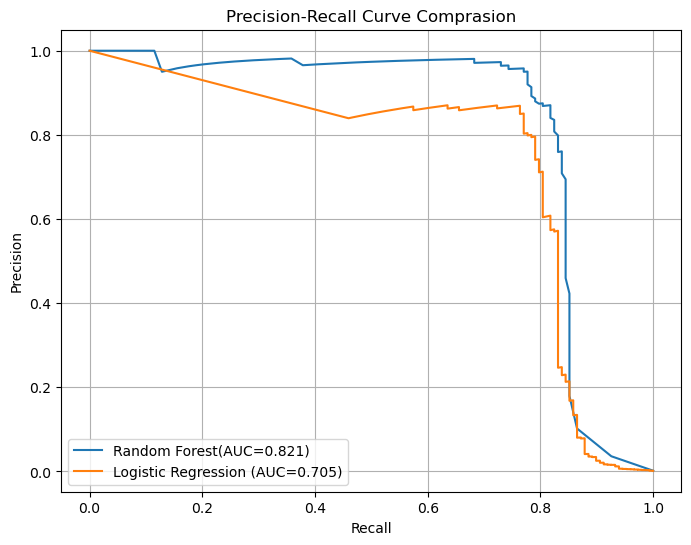

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_rf, recall_rf, _ = precision_recall_curve(y_test, proba_test)
pr_auc_rf = average_precision_score(y_test, proba_test)

precision_log, recall_log, _ = precision_recall_curve(y_test, proba_log)
pr_auc_log = average_precision_score(y_test, proba_log)

plt.figure(figsize=(8,6))

plt.plot(recall_rf, precision_rf, label = f"Random Forest(AUC={pr_auc_rf:.3f})")
plt.plot(recall_log, precision_log, label=f"Logistic Regression (AUC={pr_auc_log:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comprasion")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:,1]
print("GB PR-AUC:", average_precision_score(y_test, proba_gb))


GB PR-AUC: 0.5996819921403695


In [19]:
res_gb = scan_thresholds(y_test, proba_gb, thresholds, FP_COST, FN_COST)
best_gb = res_gb.iloc[0]

best_gb

threshold        0.091827
cost         13470.000000
tn           85248.000000
fp              47.000000
fn              26.000000
tp             122.000000
precision        0.721893
recall           0.824324
Name: 0, dtype: float64

In [20]:
best_t_gb = float(best_gb["threshold"])
pred_gb_best = (proba_gb >= best_t_gb).astype(int)
print("GB Best Threshold:", best_t_gb)
print("GB Best Cost:", int(best_gb["cost"]))
print(classification_report(y_test, pred_gb_best, digits=4))

GB Best Threshold: 0.0918265306122449
GB Best Cost: 13470
              precision    recall  f1-score   support

           0     0.9997    0.9994    0.9996     85295
           1     0.7219    0.8243    0.7697       148

    accuracy                         0.9991     85443
   macro avg     0.8608    0.9119    0.8846     85443
weighted avg     0.9992    0.9991    0.9992     85443



In [21]:
comparison_all = pd.DataFrame([
    {
        "model": "RandomForest",
        "best_cost": float(best_rf["cost"]),
        "recall": float(best_rf["recall"]),
        "precision": float(best_rf["precision"]),
        "pr_auc": average_precision_score(y_test,proba_test)
    },
    {
         "model": "Logistic",
        "best_cost": float(best_log["cost"]),
        "recall": float(best_log["recall"]),
        "precision": float(best_log["precision"]),
        "pr_auc": average_precision_score(y_test,proba_log)
    },
    {
        "model": "GradientBoosting",
        "best_cost": float(best_gb["cost"]),
        "recall": float(best_gb["recall"]),
        "precision": float(best_gb["precision"]),
        "pr_auc": average_precision_score(y_test,proba_gb)
    }
]).sort_values("best_cost")
comparison_all

,model,best_cost,recall,precision,pr_auc
0,RandomForest,12080.0,0.844595,0.683060,0.821481
1,Logistic,13460.0,0.831081,0.561644,0.704996
2,GradientBoosting,13470.0,0.824324,0.721893,0.599682


In [22]:
from xgboost import XGBClassifier
neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos

xgb= XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    random_state = RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
proba_xgb = xgb.predict_proba(X_test)[:,1]
print("XGBoost PR-AUC:", average_precision_score(y_test, proba_xgb))

XGBoost PR-AUC: 0.8080348133569208


In [23]:
res_xgb = scan_thresholds(y_test, proba_xgb, thresholds, FP_COST, FN_COST)
best_xgb = res_xgb.iloc[0]
best_xgb

threshold        0.364306
cost         12560.000000
tn           85089.000000
fp             206.000000
fn              21.000000
tp             127.000000
precision        0.381381
recall           0.858108
Name: 0, dtype: float64

In [24]:
best_t_xgb = float(best_xgb["threshold"])
pred_xgb_best = (proba_xgb >= best_t_xgb).astype(int)

print("XGB Best Threshold:", best_t_xgb)
print("XGB Best Cost:", int(best_xgb["cost"]))
print(confusion_matrix(y_test, pred_xgb_best))
print(classification_report(y_test, pred_xgb_best, digits=4))

XGB Best Threshold: 0.3643061224489796
XGB Best Cost: 12560
[[85089   206]
 [   21   127]]
              precision    recall  f1-score   support

           0     0.9998    0.9976    0.9987     85295
           1     0.3814    0.8581    0.5281       148

    accuracy                         0.9973     85443
   macro avg     0.6906    0.9278    0.7634     85443
weighted avg     0.9987    0.9973    0.9979     85443



In [25]:
comparison_all = pd.DataFrame([
    {
        "model": "RandomForest",
        "best_cost": float(best_rf["cost"]),
        "recall": float(best_rf["recall"]),
        "precision": float(best_rf["precision"]),
        "pr_auc": average_precision_score(y_test,proba_test)
    },
    {
        "model": "Logistic",
        "best_cost": float(best_log["cost"]),
        "recall": float(best_log["recall"]),
        "precision": float(best_log["precision"]),
        "pr_auc": average_precision_score(y_test,proba_log)
    },
    {
        "model": "GradientBoosting",
        "best_cost": float(best_gb["cost"]),
        "recall": float(best_gb["recall"]),
        "precision": float(best_gb["precision"]),
        "pr_auc": average_precision_score(y_test,proba_gb)
    },
    {
        "model": "XGBoost",
        "best_cost": float(best_xgb["cost"]),
        "recall": float(best_xgb["recall"]),
        "precision": float(best_xgb["precision"]),
        "pr_auc": average_precision_score(y_test, proba_xgb)
    }
]).sort_values("best_cost")
comparison_all

,model,best_cost,recall,precision,pr_auc
0,RandomForest,12080.0,0.844595,0.683060,0.821481
3,XGBoost,12560.0,0.858108,0.381381,0.808035
1,Logistic,13460.0,0.831081,0.561644,0.704996
2,GradientBoosting,13470.0,0.824324,0.721893,0.599682


In [26]:
!pip install lightgbm

In [27]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier

neg,pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg/pos

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE
)
lgbm.fit(X_train, y_train)
proba_lgbm = lgbm.predict_proba(X_test)[:,1]
print("LightGBM PR-AUC:", average_precision_score(y_test, proba_lgbm))

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001725 -> initscore=-6.360519
[LightGBM] [Info] Start training from score -6.360519
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [28]:
res_lgbm = scan_thresholds(y_test, proba_lgbm, thresholds, FP_COST, FN_COST)
best_lgbm = res_lgbm.iloc[0]

best_lgbm

threshold        0.495500
cost         27980.000000
tn           83947.000000
fp            1348.000000
fn              29.000000
tp             119.000000
precision        0.081118
recall           0.804054
Name: 0, dtype: float64

In [29]:
best_t_lgbm = float(best_lgbm["threshold"])
pred_lgbm_best = (proba_lgbm >= best_t_lgbm).astype(int)

print("LightGBM Best Threshold:", best_t_lgbm)
print("LightGBM Best Cost:", int(best_lgbm["cost"]))
print(confusion_matrix(y_test, pred_lgbm_best))
print(classification_report(y_test, pred_lgbm_best, digits=4))

LightGBM Best Threshold: 0.49549999999999994
LightGBM Best Cost: 27980
[[83947  1348]
 [   29   119]]
              precision    recall  f1-score   support

           0     0.9997    0.9842    0.9919     85295
           1     0.0811    0.8041    0.1474       148

    accuracy                         0.9839     85443
   macro avg     0.5404    0.8941    0.5696     85443
weighted avg     0.9981    0.9839    0.9904     85443



In [30]:
comparison_all = pd.DataFrame([
    {
        "model": "RandomForest",
        "best_cost": float(best_rf["cost"]),
        "recall": float(best_rf["recall"]),
        "precision": float(best_rf["precision"]),
        "pr_auc": average_precision_score(y_test, proba_test)
    },
    {
        "model": "Logistic",
        "best_cost": float(best_log["cost"]),
        "recall": float(best_log["recall"]),
        "precision": float(best_log["precision"]),
        "pr_auc": average_precision_score(y_test, proba_log)
    },
    {
        "model": "GradientBoosting",
        "best_cost": float(best_gb["cost"]),
        "recall": float(best_gb["recall"]),
        "precision": float(best_gb["precision"]),
        "pr_auc": average_precision_score(y_test, proba_gb)
    },
    {
        "model": "XGBoost",
        "best_cost": float(best_xgb["cost"]),
        "recall": float(best_xgb["recall"]),
        "precision": float(best_xgb["precision"]),
        "pr_auc": average_precision_score(y_test, proba_xgb)
    },
    {
        "model": "LightGBM",
        "best_cost": float(best_lgbm["cost"]),
        "recall": float(best_lgbm["recall"]),
        "precision": float(best_lgbm["precision"]),
        "pr_auc": average_precision_score(y_test, proba_lgbm)
    }
]).sort_values("best_cost")

comparison_all

,model,best_cost,recall,precision,pr_auc
0,RandomForest,12080.0,0.844595,0.683060,0.821481
3,XGBoost,12560.0,0.858108,0.381381,0.808035
1,Logistic,13460.0,0.831081,0.561644,0.704996
2,GradientBoosting,13470.0,0.824324,0.721893,0.599682
4,LightGBM,27980.0,0.804054,0.081118,0.065563


In [31]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_,
    "model":"RandomForest"
}).sort_values("importance", ascending=False)
feat_imp.head(10)

,feature,importance,model
14,V14,0.167173,RandomForest
4,V4,0.136910,RandomForest
10,V10,0.123025,RandomForest
12,V12,0.093821,RandomForest
17,V17,0.088198,RandomForest
16,V16,0.056058,RandomForest
11,V11,0.055583,RandomForest
3,V3,0.053977,RandomForest
2,V2,0.027221,RandomForest
9,V9,0.021824,RandomForest


In [37]:
feat_imp_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_,
    "model": "RandomForest"
}).sort_values("importance", ascending=False)

feat_imp_rf.head()

,feature,importance,model
14,V14,0.167173,RandomForest
4,V4,0.136910,RandomForest
10,V10,0.123025,RandomForest
12,V12,0.093821,RandomForest
17,V17,0.088198,RandomForest


In [39]:
feat_imp_xgb = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_,
    "model": "XGBoost"
}).sort_values("importance", ascending=False)

feat_imp_xgb.head()

,feature,importance,model
14,V14,0.278859,XGBoost
10,V10,0.125684,XGBoost
4,V4,0.072449,XGBoost
12,V12,0.059183,XGBoost
20,V20,0.047780,XGBoost


In [40]:
feature_importance_all = pd.concat([feat_imp_rf, feat_imp_xgb], ignore_index=True)
feature_importance_all.head()

,feature,importance,model
0,V14,0.167173,RandomForest
1,V4,0.136910,RandomForest
2,V10,0.123025,RandomForest
3,V12,0.093821,RandomForest
4,V17,0.088198,RandomForest


In [41]:
feature_importance_all.to_csv("feature_importance_all.csv", index=False)

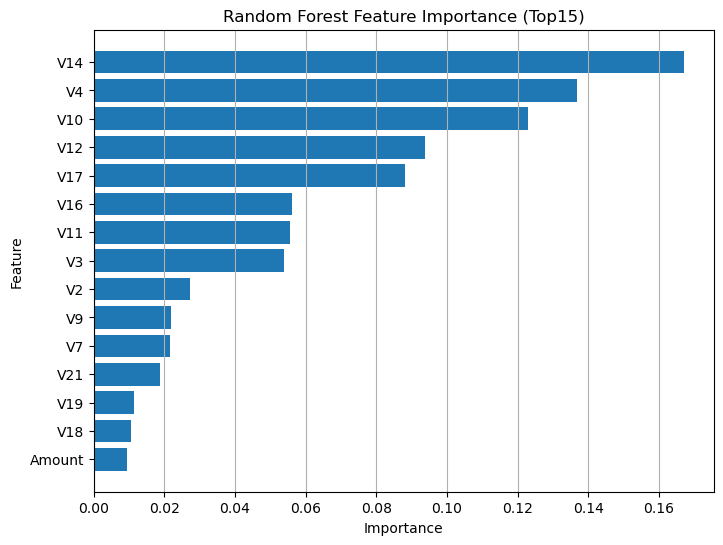

In [32]:
import matplotlib.pyplot as plt
top_rf = feat_imp.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance (Top15)")
plt.grid(True, axis="x")
plt.show()

In [33]:
feat_imp_xgb = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_,
    "model": "XGBoost"
}).sort_values("importance", ascending=False)

feat_imp_xgb.head(10)

,feature,importance,model
14,V14,0.278859,XGBoost
10,V10,0.125684,XGBoost
4,V4,0.072449,XGBoost
12,V12,0.059183,XGBoost
20,V20,0.047780,XGBoost
8,V8,0.030850,XGBoost
29,Amount,0.026095,XGBoost
21,V21,0.025505,XGBoost
19,V19,0.024813,XGBoost
3,V3,0.021659,XGBoost


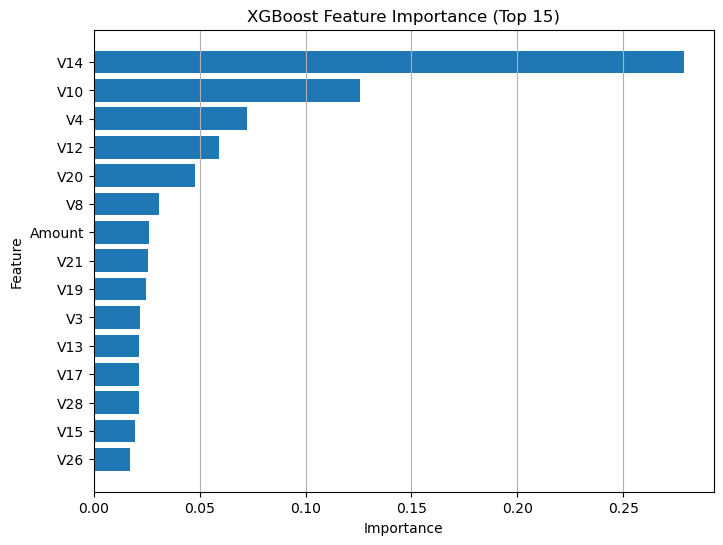

In [34]:
top_xgb = feat_imp_xgb.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(top_xgb["feature"], top_xgb["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance (Top 15)")
plt.grid(True, axis="x")
plt.show()

In [42]:
feature_importance_all = pd.concat([feat_imp_rf, feat_imp_xgb], ignore_index=True)
feature_importance_all.to_csv("feature_importance_all.csv", index=False)

In [43]:
comparison_all.to_csv("model_comparison.csv", index=False)
feat_imp.to_csv("feature_importance.csv", index=False)

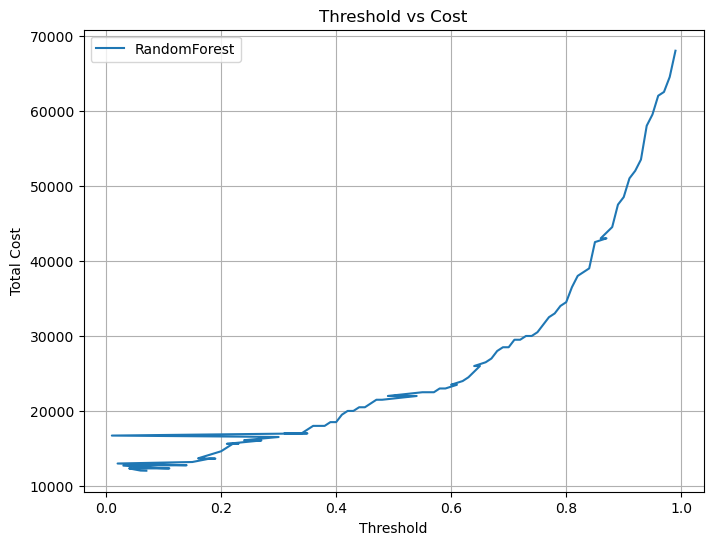

In [44]:
plt.figure(figsize=(8,6))

plt.plot(res["threshold"], res["cost"], label="RandomForest")

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Cost")
plt.legend()
plt.grid(True)
plt.show()

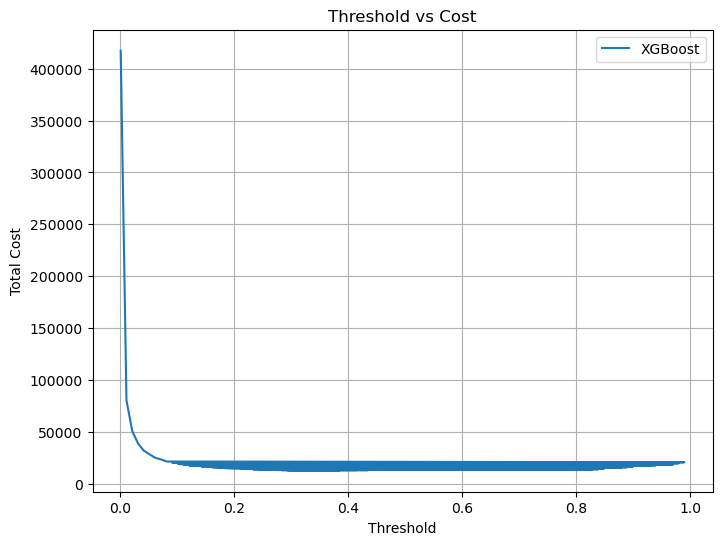

In [45]:
plt.figure(figsize=(8,6))

plt.plot(res_xgb["threshold"], res_xgb["cost"], label="XGBoost")

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Cost")
plt.legend()
plt.grid(True)
plt.show()

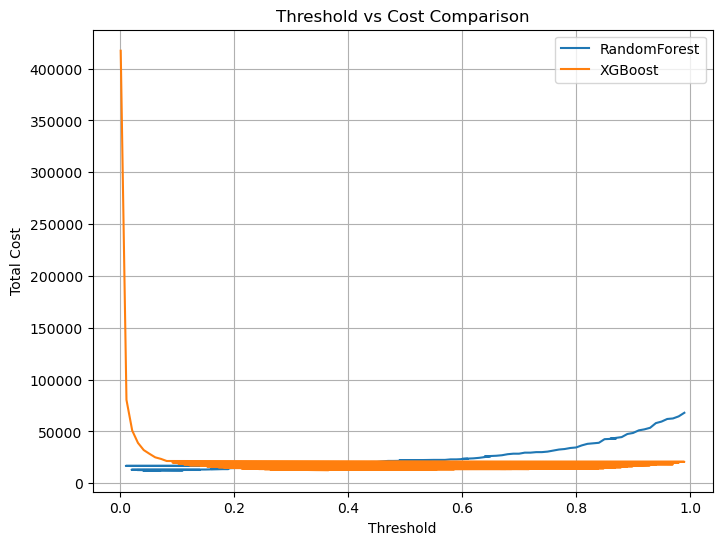

In [46]:
plt.figure(figsize=(8,6))

plt.plot(res["threshold"], res["cost"], label="RandomForest")
plt.plot(res_xgb["threshold"], res_xgb["cost"], label="XGBoost")

plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Cost Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
!pip install shap

In [49]:
import shap

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
explainer = shap.Explainer(xgb, X_shap)
shap_values = explainer(X_shap)

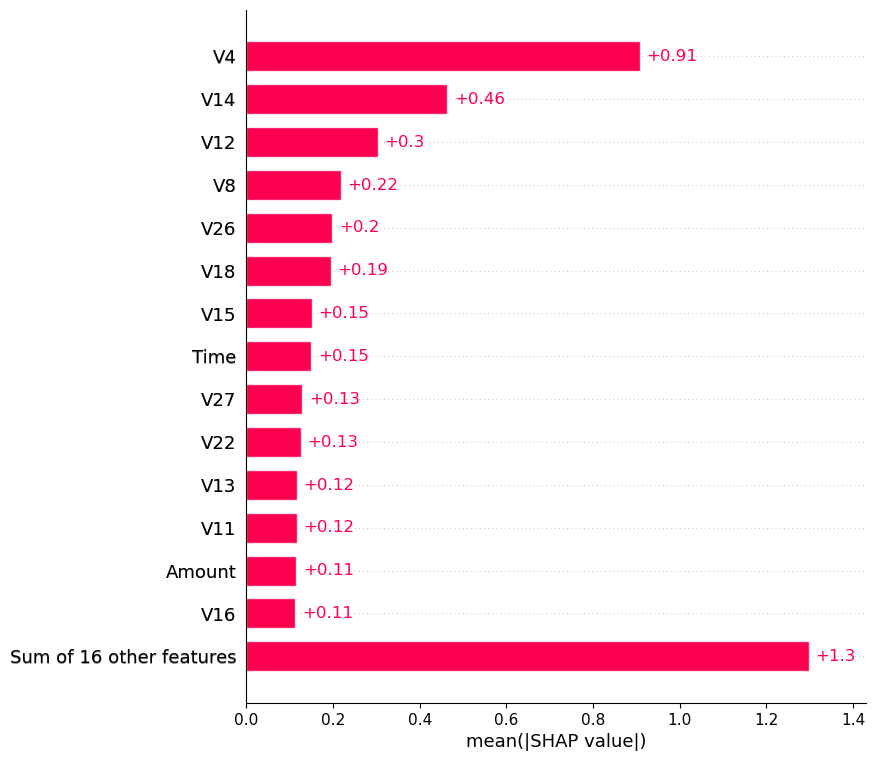

In [50]:
shap.plots.bar(shap_values, max_display=15)
plt.show()

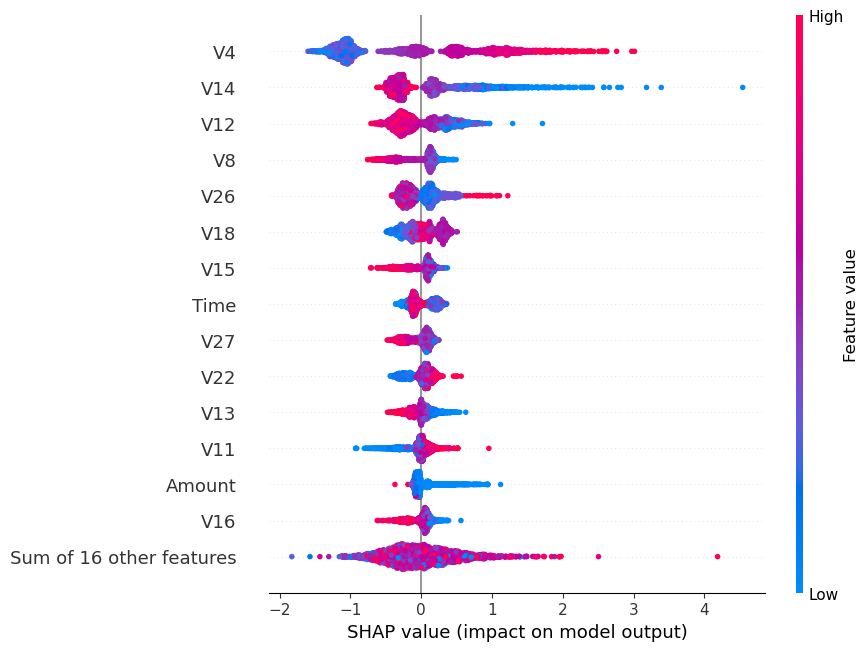

In [51]:
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

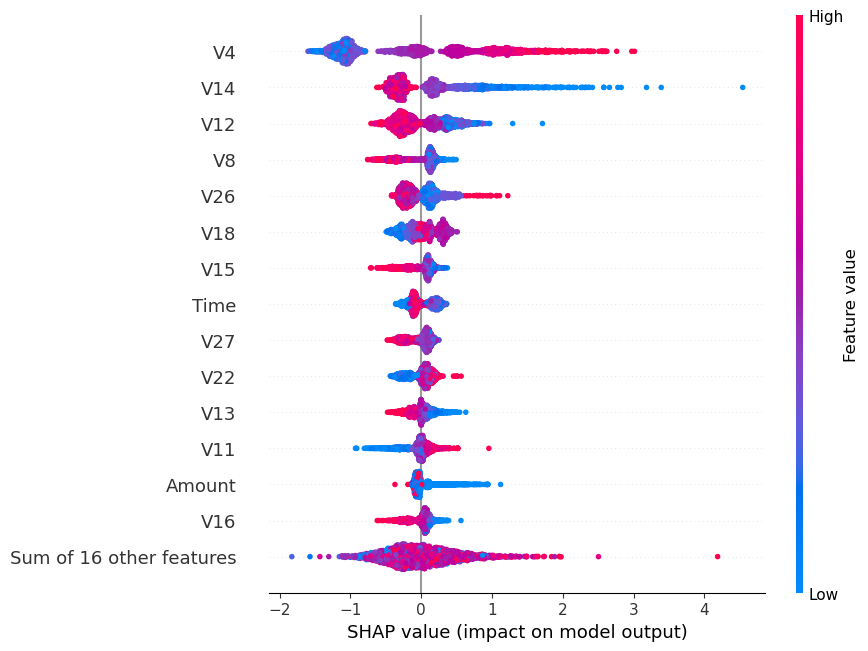

In [52]:
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

In [53]:
proba_shap = xgb.predict_proba(X_shap)[:, 1]

In [54]:
best_t_xgb = 0.07

In [55]:
pred_shap = (proba_shap >= best_t_xgb).astype(int)

fraud_idx_list = np.where(pred_shap == 1)[0]
fraud_idx = fraud_idx_list[0]

print("Seçilen gözlem:", fraud_idx)
print("Gerçek etiket:", y_test.loc[X_shap.index[fraud_idx]])
print("Tahmin olasılığı:", proba_shap[fraud_idx])

Seçilen gözlem: 30
Gerçek etiket: 0
Tahmin olasılığı: 0.19323619


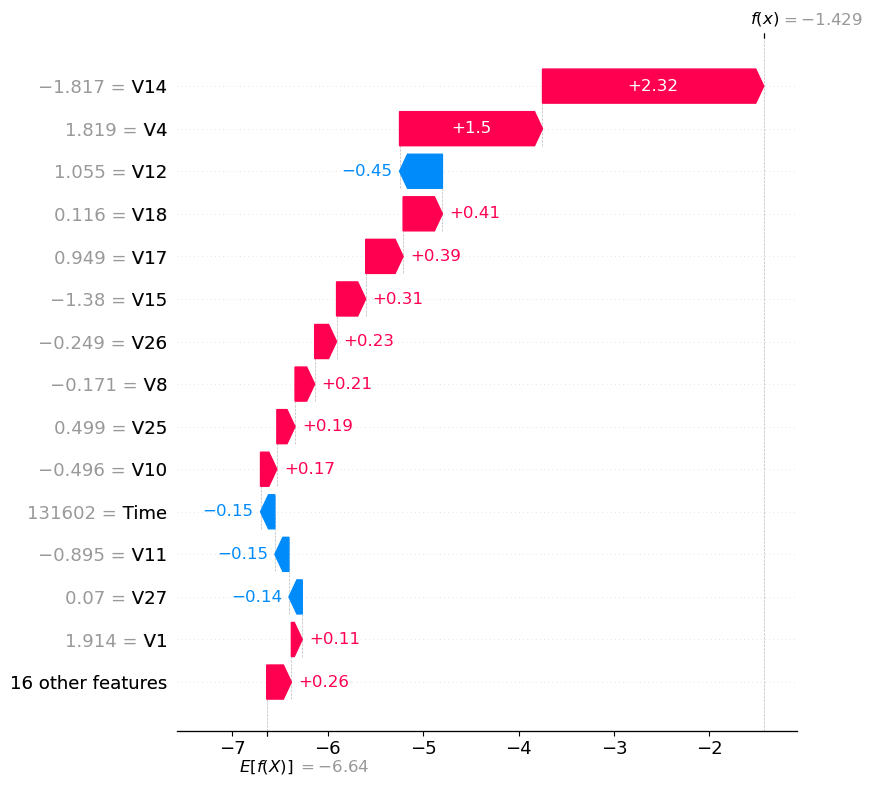

In [56]:
shap.plots.waterfall(shap_values[fraud_idx], max_display=15)
plt.show()

In [57]:
local_exp = pd.DataFrame({
    "feature": X_shap.columns,
    "feature_value": X_shap.iloc[fraud_idx].values,
    "shap_value": shap_values.values[fraud_idx]
}).sort_values("shap_value", ascending=False)
local_exp.head(15)

,feature,feature_value,shap_value
14,V14,-1.817042,2.319668
4,V4,1.819207,1.498711
18,V18,0.116351,0.411984
17,V17,0.948701,0.392394
15,V15,-1.380331,0.305373
26,V26,-0.248691,0.229438
8,V8,-0.171329,0.205932
25,V25,0.498897,0.190624
10,V10,-0.495607,0.171384
1,V1,1.913787,0.114091


In [58]:
local_exp.to_csv("xgb_local_shap_explanation.csv", index=False)

In [59]:
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
4,V4,0.907124
14,V14,0.463928
12,V12,0.304045
8,V8,0.217229
26,V26,0.198663
18,V18,0.194184
15,V15,0.151328
0,Time,0.149734
27,V27,0.129027
22,V22,0.126321


In [60]:
shap_importance.to_csv("xgb_shap_importance.csv", index=False)

In [61]:
# RandomForest
res_rf = scan_thresholds(y_test, proba_test, thresholds, FP_COST, FN_COST)
res_rf["model"] = "RandomForest"

# XGBoost
res_xgb = scan_thresholds(y_test, proba_xgb, thresholds, FP_COST, FN_COST)
res_xgb["model"] = "XGBoost"

# Logistic Regression
res_log = scan_thresholds(y_test, proba_log, thresholds, FP_COST, FN_COST)
res_log["model"] = "Logistic"

# Gradient Boosting
res_gb = scan_thresholds(y_test, proba_gb, thresholds, FP_COST, FN_COST)
res_gb["model"] = "GradientBoosting"

In [63]:
res_lgb = scan_thresholds(y_test, proba_lgbm, thresholds, FP_COST, FN_COST)
res_lgb["model"] = "LightGBM"

In [65]:
threshold_scan_all = pd.concat(
    [res_rf, res_xgb, res_log, res_gb, res_lgb],
    ignore_index=True
)

In [66]:
threshold_scan_all.to_csv("threshold_scan_all.csv", index=False)